In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE = Path("/content/drive/MyDrive/SoSe2026/DSESM/HW4/Data")

list(BASE.iterdir())

Mounted at /content/drive


[PosixPath('/content/drive/MyDrive/SoSe2026/DSESM/HW4/Data/RAW'),
 PosixPath('/content/drive/MyDrive/SoSe2026/DSESM/HW4/Data/PROCESSED')]

Definition of Model Regions for Austria

In [2]:
from pathlib import Path
import geopandas as gpd

RAW = BASE / "RAW"
PROCESSED = BASE / "PROCESSED"

gadm_path = RAW / "gadm" / "gadm_410-levels-ADM_1-AUT.gpkg"

gadm = gpd.read_file(gadm_path)

# Show basic information
print("Columns:", gadm.columns.tolist())
print("CRS:", gadm.crs)
print("Number of regions:", len(gadm))
print("Country codes:", gadm["GID_0"].unique())
print("Country names:", gadm["COUNTRY"].unique())
print(gadm[["GID_1", "NAME_1"]])

# Save clean copy
gadm.to_file(PROCESSED / "gadm_aut_level1.geojson", driver="GeoJSON")

Columns: ['GID_0', 'GID_1', 'COUNTRY', 'NAME_1', 'geometry']
CRS: EPSG:4326
Number of regions: 9
Country codes: ['AUT']
Country names: ['Austria']
     GID_1            NAME_1
0  AUT.1_1        Burgenland
1  AUT.2_1           Kärnten
2  AUT.3_1  Niederösterreich
3  AUT.4_1    Oberösterreich
4  AUT.5_1          Salzburg
5  AUT.6_1        Steiermark
6  AUT.7_1             Tirol
7  AUT.8_1        Vorarlberg
8  AUT.9_1              Wien


EEZ : Austria is a landlocked country; therefore, no Marine Regions or EEZ data are required.

Define Centroids of Each Region

In [3]:
# Project to a metric CRS, since .centroid works with projected coordinates.
gadm_projected = gadm.to_crs("EPSG:3035")

# Calculate centroids and convert back to WGS84
centroids = gadm_projected.geometry.centroid.to_crs("EPSG:4326")

# Create a new dataframe containing only region names and centroids
region_centroids = gpd.GeoDataFrame(
    {
        "GID": gadm["GID_1"],
        "region": gadm["NAME_1"],
        "geometry": centroids
    },
    crs="EPSG:4326"
)

# Longitude and latitude
region_centroids["x"] = region_centroids.geometry.x
region_centroids["y"] = region_centroids.geometry.y

# Save centroids
region_centroids.to_file(
    PROCESSED / "austria_region_centroids.geojson",
    driver="GeoJSON"
)

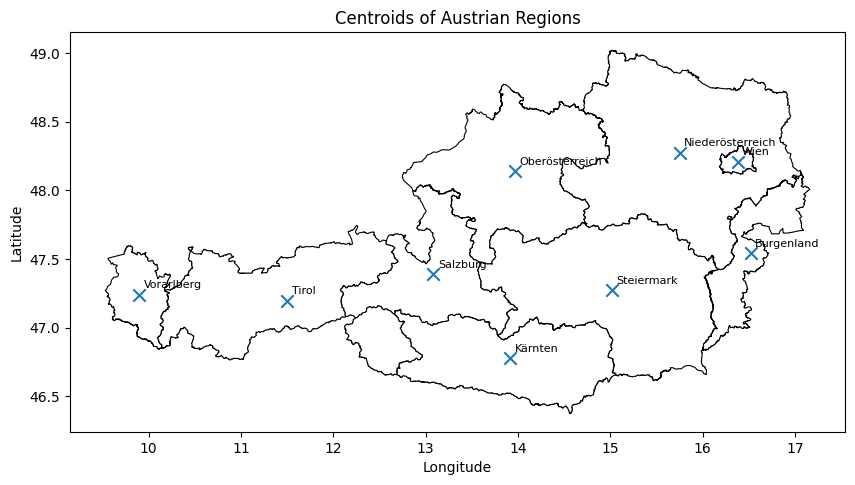

In [6]:
import matplotlib.pyplot as plt

#Visual for centroids
ax = gadm.plot(figsize=(10, 6),edgecolor="black",facecolor="white",linewidth=0.8)

plt.scatter(region_centroids["x"],region_centroids["y"],marker="x",s=80)

for _, row in region_centroids.iterrows():
    plt.text(row["x"] + 0.05, row["y"] + 0.05, row["region"], fontsize=8)

plt.title("Centroids of Austrian Regions")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Land Eligibility Analysis

In [7]:
!import atlite
!pip install atlite

/bin/bash: line 1: import: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.0/131.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 92.0 MB/s eta 0:00:00


In [8]:
import pandas as pd
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show

Solar Eligible Areas

In [16]:
import rasterio
import numpy as np

landcover_path = (
    RAW
    / "copernicus-glc"
    / "PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-AT.tif"
)

landcover = rasterio.open(landcover_path)

#Finding class codes

#landcover_data = landcover.read(1)
#valid_values = landcover_data[landcover_data != landcover.nodata]
#unique_codes = np.unique(valid_values)

suitable_land_codes = [20, 30, 40, 60]

wdpa_path = RAW / "wdpa" / "WDPA_Oct2022_Public_shp-AUT.tif"

In [18]:
solar_excluder = ExclusionContainer(crs=3035, res=100)

# protected areas
solar_excluder.add_raster(
    wdpa_path,
    nodata=255
)

#Cornelius suitable areas
solar_excluder.add_raster(
    landcover_path,
    codes=suitable_land_codes,
    invert=True,
    nodata=255
)

#Creating the mask
regions_m = gadm.to_crs("EPSG:3035")

solar_availability, solar_transform = shape_availability(
    regions_m.geometry,
    solar_excluder
)

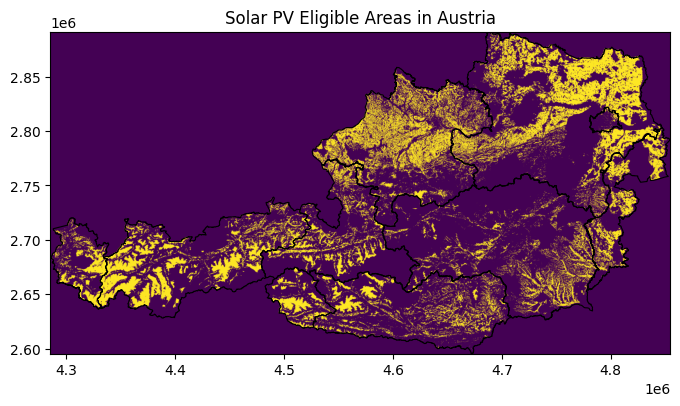

In [19]:
import matplotlib.pyplot as plt
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(8, 8))

show(
    solar_availability,
    transform=solar_transform,
    ax=ax
)

regions_m.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8
)

ax.set_title("Solar PV Eligible Areas in Austria")
plt.show()

Onshore Wind Eligible Areas

In [24]:
wind_excluder = ExclusionContainer(crs=3035, res=100)

# protected areas
wind_excluder.add_raster(
    wdpa_path,
    nodata=255
)

#Cornelius suitable areas
wind_excluder.add_raster(
    landcover_path,
    codes=suitable_land_codes,
    invert=True,
    nodata=255
)

####### Airports

# Read airport data
airports_path = RAW / "ne_10m_airports.gpkg"
airports = gpd.read_file(airports_path)

# Project to metric CRS
airports_m = airports.to_crs("EPSG:3035")

# Austria regions in metric CRS
regions_m = gadm.to_crs("EPSG:3035")

# Keep only airports inside Austria
airports_aut = gpd.sjoin(
    airports_m,
    regions_m[["geometry"]],
    how="inner",
    predicate="within"
)

airports_aut.head()

# airports buffer
wind_excluder.add_geometry(
    airports_aut.geometry,
    buffer=10_000
)

# Road buffer
roads_path = RAW / "ne_10m_roads.gpkg"
roads = gpd.read_file(roads_path)

roads_m = roads.to_crs("EPSG:3035")
regions_m = gadm.to_crs("EPSG:3035").set_index("NAME_1")

roads_aut = gpd.sjoin(
    roads_m,
    regions_m[["geometry"]],
    how="inner",
    predicate="intersects"
)

wind_excluder.add_geometry(
    roads_aut.geometry,
    buffer=300
)

# build up
wind_excluder.add_raster(
    landcover_path,
    codes=[50],
    buffer=1000,
    nodata=255
)

#elevation
elevation_path = RAW / "gebco" / "GEBCO_2014_2D-AT.nc"

wind_excluder.add_raster(
    elevation_path,
    codes=lambda x: x > 2000,
    crs=4326 # Manually specify CRS as EPSG:4326 for GEBCO data
)

In [25]:
wind_availability, wind_transform = shape_availability(
    regions_m.geometry,
    wind_excluder
)

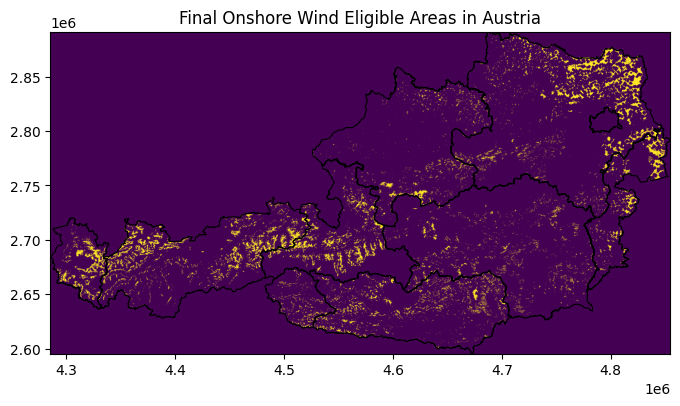

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

show(
    wind_availability,
    transform=wind_transform,
    ax=ax
)

regions_m.boundary.plot(ax=ax, color="black", linewidth=0.8)

ax.set_title("Final Onshore Wind Eligible Areas in Austria")
plt.show()